Preliminary Work

shape: (66_989, 6)
┌────────┬────────┬────────┬─────────┬───────────┬─────────────────┐
│ chr    ┆ start  ┆ end    ┆ smt_pos ┆ smt_value ┆ fuzziness_score │
│ ---    ┆ ---    ┆ ---    ┆ ---     ┆ ---       ┆ ---             │
│ str    ┆ i64    ┆ i64    ┆ i64     ┆ f64       ┆ f64             │
╞════════╪════════╪════════╪═════════╪═══════════╪═════════════════╡
│ chrI   ┆ 80     ┆ 228    ┆ 154     ┆ 160.0     ┆ 62.229963       │
│ chrI   ┆ 183    ┆ 331    ┆ 257     ┆ 560.0     ┆ 51.164821       │
│ chrI   ┆ 343    ┆ 491    ┆ 417     ┆ 560.0     ┆ 51.520939       │
│ chrI   ┆ 463    ┆ 611    ┆ 537     ┆ 160.0     ┆ 63.879253       │
│ chrI   ┆ 591    ┆ 739    ┆ 665     ┆ 160.0     ┆ 68.714923       │
│ …      ┆ …      ┆ …      ┆ …       ┆ …         ┆ …               │
│ chrXVI ┆ 942744 ┆ 942892 ┆ 942818  ┆ 56240.0   ┆ 42.835329       │
│ chrXVI ┆ 943093 ┆ 943241 ┆ 943167  ┆ 8080.0    ┆ 44.624281       │
│ chrXVI ┆ 943256 ┆ 943404 ┆ 943330  ┆ 3680.0    ┆ 52.267879       │
│ chrXVI ┆ 9462

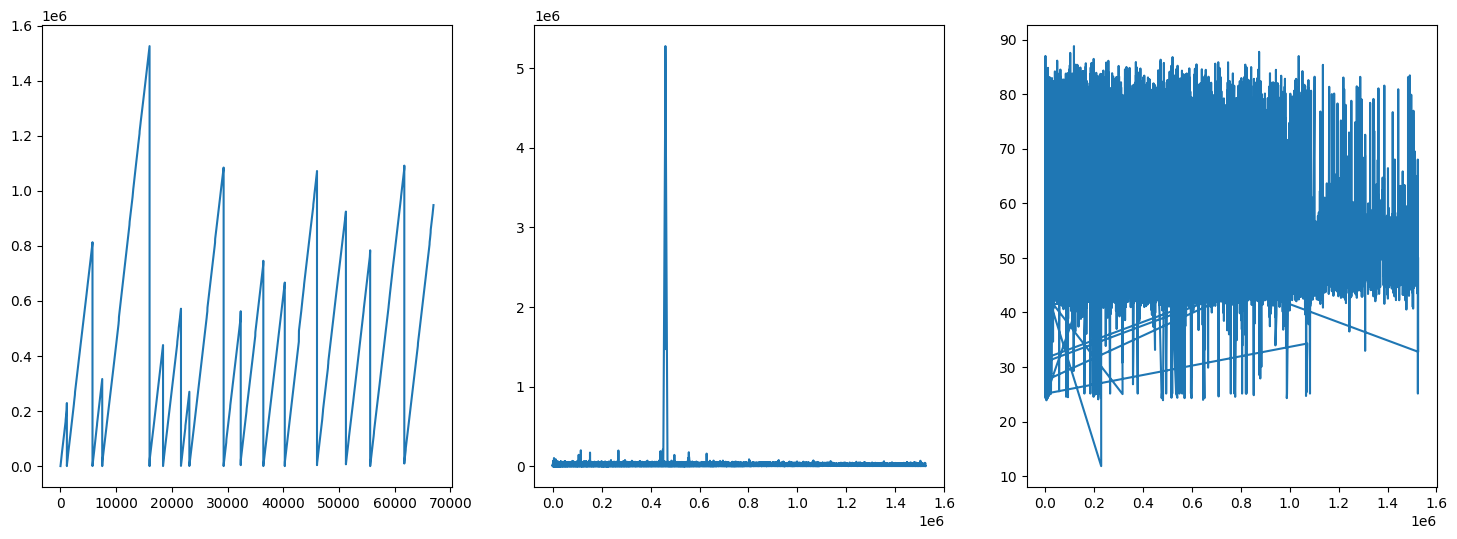

shape: (28, 7)
┌───────┬────────┬────────┬─────────┬───────────┬─────────────────┬──────┐
│ chr   ┆ start  ┆ end    ┆ smt_pos ┆ smt_value ┆ fuzziness_score ┆ NRLs │
│ ---   ┆ ---    ┆ ---    ┆ ---     ┆ ---       ┆ ---             ┆ ---  │
│ str   ┆ i64    ┆ i64    ┆ i64     ┆ f64       ┆ f64             ┆ i64  │
╞═══════╪════════╪════════╪═════════╪═══════════╪═════════════════╪══════╡
│ chrII ┆ 250046 ┆ 250194 ┆ 250120  ┆ 27920.0   ┆ 49.93494        ┆ 0    │
│ chrII ┆ 250206 ┆ 250354 ┆ 250280  ┆ 19200.0   ┆ 56.326189       ┆ 160  │
│ chrII ┆ 250361 ┆ 250509 ┆ 250435  ┆ 30800.0   ┆ 49.229435       ┆ 155  │
│ chrII ┆ 250521 ┆ 250669 ┆ 250595  ┆ 30720.0   ┆ 50.194767       ┆ 160  │
│ chrII ┆ 250680 ┆ 250828 ┆ 250754  ┆ 27760.0   ┆ 50.488028       ┆ 159  │
│ …     ┆ …      ┆ …      ┆ …       ┆ …         ┆ …               ┆ …    │
│ chrII ┆ 253976 ┆ 254124 ┆ 254050  ┆ 29200.0   ┆ 49.97341        ┆ 157  │
│ chrII ┆ 254141 ┆ 254289 ┆ 254215  ┆ 24720.0   ┆ 52.38293        ┆ 165  │
│ chrII ┆ 

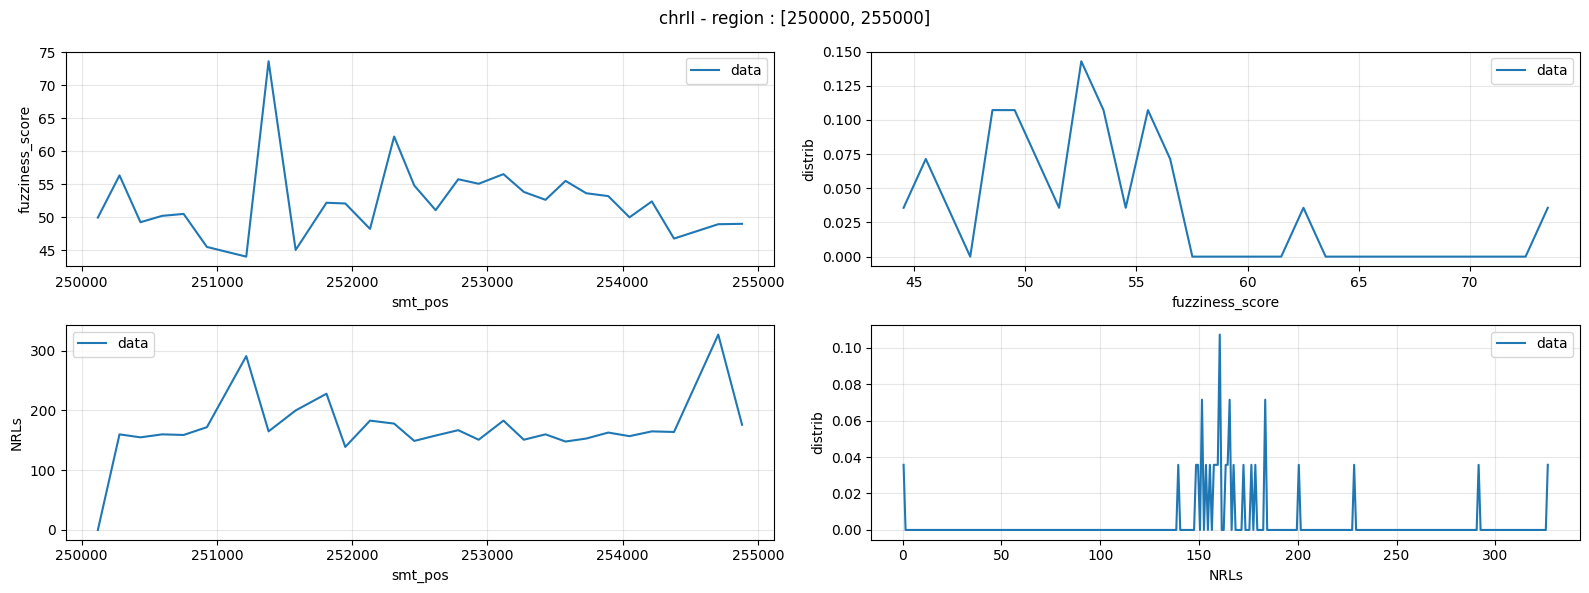

In [1]:
# ── Imports ──────────────────────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import polars as pl

from nucleo.metrics.utils import clc_distrib


# ── Load files ───────────────────────────────────────────────────────────────
root = Path("/home/nicolas/Documents/Workspace/nucleo/outputs/NUC/danpos.s2.xls")
df_ATAC = pl.read_csv(
    root,
    separator="\t"
)
print(df_ATAC)


# ── Values ───────────────────────────────────────────────────────────────
CHROMOSOMES     = df_ATAC["chr"].to_numpy()
SMT_POS         = df_ATAC["smt_pos"].to_numpy()
SMT_VALUE       = df_ATAC["smt_value"].to_numpy()
FUZZINESS_SCORE = df_ATAC["fuzziness_score"].to_numpy()
NRLS            = np.diff(df_ATAC["smt_pos"].to_numpy())


# ── Functions ───────────────────────────────────────────────────────────────
def select_region(df, chrom=None, region=None, gap=np.inf):
    condition = pl.col("smt_value") < gap
    if chrom is not None:
        condition &= pl.col("chr") == chrom
    if region is not None:
        condition &= pl.col("smt_pos").is_between(*region)
    return df.filter(condition)

def clc_fuziness_distrib(df: pl.DataFrame):
    fuzziness_score = df["fuzziness_score"].to_numpy()
    return (clc_distrib(
        data=fuzziness_score,
        first_bin=np.min(fuzziness_score),
        last_bin=np.max(fuzziness_score),
        bin_width=1
        )
    )

def clc_NRLs_distrib(df: pl.DataFrame, NRLS: np.ndarray):
    return(clc_distrib(
        data=NRLS,
        first_bin=np.min(NRLS),
        last_bin=np.max(NRLS),
        bin_width=1
        )
    )


# ── Plots over all the genome + Raw values ───────────────────────────────────────────────────────────────
fig, (ax0, ax1, ax2) = plt.subplots(figsize=(18,6), ncols=3, nrows=1)
ax0.plot(SMT_POS)
ax1.plot(SMT_POS, SMT_VALUE)
ax2.plot(SMT_POS, FUZZINESS_SCORE)
plt.show()


# ─ Nous sommes obligés de compartimenter par chromosome sinon ça n'a aucun sens ───────────────────────────────────────────────────────────────
# ── Region ───────────────────────────────────────────────────────────────
chrom   = "chrII"
region  = [250_000, 255_000]
gap     = 1e4

df_region = select_region(
    df_ATAC,
    chrom=chrom,
    region = region,
    gap=1e6,
)

df_region = df_region.with_columns(
    NRLs = np.concatenate(([0], np.diff(df_region["smt_pos"].to_numpy())))
)

print(df_region)


# ── Plots on one specific region + Distributions ───────────────────────────────────────────────────────────────
x1, y1 = df_region["smt_pos"], df_region["fuzziness_score"]
x2, y2 = clc_fuziness_distrib(df_region)
x3, y3 = df_region["smt_pos"], df_region["NRLs"]
x4, y4 = clc_NRLs_distrib(df_region, df_region["NRLs"].to_numpy())


# Plotting
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(ncols=2, nrows=2, figsize=(16, 6))
fig.suptitle(f"{chrom} - region : {region}")

ax1.plot(x1, y1, label="data")
ax1.set_xlabel("smt_pos")
ax1.set_ylabel("fuzziness_score")
ax1.grid(True, which="both", alpha=0.3)
ax1.legend(loc="best")

ax2.plot(x2, y2, label="data")
ax2.set_xlabel("fuzziness_score")
ax2.set_ylabel("distrib")
ax2.grid(True, which="both", alpha=0.3)
ax2.legend(loc="best")

ax3.plot(x3, y3, label="data")
ax3.set_xlabel("smt_pos")
ax3.set_ylabel("NRLs")
ax3.grid(True, which="both", alpha=0.3)
ax3.legend(loc="best")

ax4.plot(x4, y4, label="data")
ax4.set_xlabel("NRLs")
ax4.set_ylabel("distrib")
ax4.grid(True, which="both", alpha=0.3)
ax4.legend(loc="best")

plt.tight_layout()
plt.show()

Etudier les CARs

- prendre la liste des CARs de Dario issues de son dernier papier
- entre chaque NN CARs i et j : calculer le NRL median dans cette région, la fuzzyness médiane et la somme de tous les smt_value/divisé par la taille du domaine.

In [7]:
CARs_df_NN = pl.read_parquet("CARs_df_NN.parquet")

In [8]:
CARs_df_NN

chrom1,start1,end1,CAR strength1,chrom2,start2,end2,CAR strength2
str,f64,f64,f64,str,f64,f64,f64
"""chrI""",1279.0,1279.0,4.139287,"""chrI""",12753.0,12753.0,2.736527
"""chrI""",12753.0,12753.0,2.736527,"""chrI""",28578.0,28578.0,11.422373
"""chrI""",28578.0,28578.0,11.422373,"""chrI""",30655.0,30655.0,11.147047
"""chrI""",30655.0,30655.0,11.147047,"""chrI""",42871.0,42871.0,4.523529
"""chrI""",42871.0,42871.0,4.523529,"""chrI""",51760.0,51760.0,67.978645
…,…,…,…,…,…,…,…
"""chrXVI""",904223.0,904223.0,1.875988,"""chrXVI""",909629.0,909629.0,14.050758
"""chrXVI""",909629.0,909629.0,14.050758,"""chrXVI""",916989.0,916989.0,32.328931
"""chrXVI""",916989.0,916989.0,32.328931,"""chrXVI""",921128.0,921128.0,7.808048


In [9]:
# ── Imports ──────────────────────────────────────────────────────────────────
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import polars as pl

from nucleo.metrics.utils import clc_distrib


# ── DataFrame : CARs ──────────────────────────────────────────────────────────────────
CARs_df_NN = pl.read_parquet("CARs_df_NN.parquet")


# ── DataFrame : NRLs ───────────────────────────────────────────────────────────────
root = Path("/home/nicolas/Documents/Workspace/nucleo/outputs/NUC/danpos.s2.xls")
df_ATAC = pl.read_csv(
    root,
    separator="\t"
)

# ── Getting Data ──────────────────────────────────────────────────────────────────
df_CARs = (
    CARs_df_NN
    .filter(pl.col("chrom1") == pl.col("chrom2"))
    .drop(
        ["end1", "CAR strength1", "chrom2", "end2", "CAR strength2"]
    )
    .rename({
    "chrom1": "CHROM",
    "start1": "CAR_i",
    "start2": "CAR_j",
    })
)

# ── Adding Empty Columns ──────────────────────────────────────────────────────────────────
df_CARs = df_CARs.with_columns(
    pl.lit(None).alias("smt_pos"),
    pl.lit(None).alias("smt_value"),
    pl.lit(None).alias("fuzziness_score"),
    pl.lit(None).alias("NRLs")
)


# ── Ajout d'un identifiant unique à chaque CAR (idempotent) ─────────────────
if "car_idx" in df_CARs.columns:
    df_CARs = df_CARs.drop("car_idx")
df_CARs = df_CARs.with_row_index("car_idx")

# ── Préparation de df_ATAC ────────────────────────────────────────────────
atac = df_ATAC.rename({"chr": "CHROM", "fuzziness_score": "fuzziness_score"}).with_columns(
    pl.col("smt_pos").cast(pl.Float64)
)

# ── Jointure par intervalle ──────────────────────────────────────────────
joined = (
    df_CARs.select(["car_idx", "CHROM", "CAR_i", "CAR_j"])
    .join_where(
        atac,
        pl.col("CHROM") == pl.col("CHROM_right"),
        pl.col("smt_pos") > pl.col("CAR_i"),
        pl.col("smt_pos") < pl.col("CAR_j"),
    )
)

# ── Regroupement + tri des smt_pos avant diff ────────────────────────────
grouped = (
    joined.group_by("car_idx")
    .agg(
        pl.col("smt_pos"),
        pl.col("smt_value"),
        pl.col("fuzziness_score"),
    )
    .with_columns(
        # on trie les 3 listes ensemble selon smt_pos
        pl.col("smt_pos").list.eval(pl.element().sort()).alias("smt_pos_sorted"),
    )
)

# Trier smt_pos, smt_value, fuzziness_score ensemble par ordre de smt_pos,
# puis calculer les NRLs (diff consécutifs des positions triées)
grouped = joined.sort(["car_idx", "smt_pos"]).group_by("car_idx", maintain_order=True).agg(
    pl.col("smt_pos"),
    pl.col("smt_value"),
    pl.col("fuzziness_score"),
    pl.col("smt_pos").diff().slice(1).alias("NRLs"),
)

# ── Fusion dans df_CARs ──────────────────────────────────────────────────
df_CARs = (
    df_CARs.drop(["smt_pos", "smt_value", "fuzziness_score", "NRLs"])
    .join(grouped, on="car_idx", how="left")
    .drop("car_idx")
)

df_CARs = df_CARs.with_columns(
    pl.col("smt_pos").fill_null([]),
    pl.col("smt_value").fill_null([]),
    pl.col("fuzziness_score").fill_null([]),
    pl.col("NRLs").fill_null([]),
)

df_CARs = df_CARs.with_columns(
    pl.col("NRLs").list.median().alias("NRLs_median"),
    pl.col("fuzziness_score").list.median().alias("fuzziness_median"),
    pl.col("smt_value").list.median().alias("smt_median"),
    pl.col("smt_value").list.len().alias("N_nuc"),
    (pl.col("smt_value").list.sum() / (pl.col("CAR_j") - pl.col("CAR_i"))).alias("smt_density"),
)
# Rajouter le smt median et le nombre de nucléosomes


# ── Save ──────────────────────────────────────────────────
df_CARs.write_parquet("df_CARs.parquet")

In [10]:
df_CARs

CHROM,CAR_i,CAR_j,smt_pos,smt_value,fuzziness_score,NRLs,NRLs_median,fuzziness_median,smt_median,N_nuc,smt_density
str,f64,f64,list[f64],list[f64],list[f64],list[f64],f64,f64,f64,u32,f64
"""chrI""",1279.0,12753.0,"[1382.0, 1572.0, … 12750.0]","[320.0, 320.0, … 80.0]","[36.249658, 42.578884, … 62.458583]","[190.0, 193.0, … 232.0]",163.5,51.277971,320.0,67,2.691302
"""chrI""",12753.0,28578.0,"[12887.0, 13189.0, … 28518.0]","[400.0, 240.0, … 6800.0]","[46.962864, 47.88268, … 50.815656]","[302.0, 164.0, … 177.0]",173.0,49.636342,240.0,70,6.010742
"""chrI""",28578.0,30655.0,"[28635.0, 28794.0, … 30587.0]","[2000.0, 35280.0, … 240.0]","[73.767381, 44.42848, … 54.757609]","[159.0, 188.0, … 184.0]",181.0,54.672343,480.0,11,22.840636
"""chrI""",30655.0,42871.0,"[30709.0, 30882.0, … 42717.0]","[320.0, 3040.0, … 21040.0]","[57.264245, 42.361516, … 45.468554]","[173.0, 150.0, … 162.0]",168.0,52.458293,20800.0,69,118.290766
"""chrI""",42871.0,51760.0,"[42915.0, 43112.0, … 51604.0]","[23120.0, 20400.0, … 34800.0]","[49.292833, 55.618137, … 54.558545]","[197.0, 171.0, … 186.0]",168.0,52.408707,23440.0,52,139.777253
…,…,…,…,…,…,…,…,…,…,…,…
"""chrXVI""",904223.0,909629.0,"[904273.0, 904446.0, … 909615.0]","[33920.0, 31840.0, … 22000.0]","[51.302253, 51.835695, … 56.18152]","[173.0, 165.0, … 151.0]",170.0,53.777259,26120.0,32,153.784684
"""chrXVI""",909629.0,916989.0,"[909716.0, 909816.0, … 916883.0]","[15920.0, 24880.0, … 31280.0]","[61.513763, 53.060301, … 55.060539]","[100.0, 166.0, … 174.0]",168.0,52.97451,25040.0,44,152.586957
"""chrXVI""",916989.0,921128.0,"[917078.0, 917241.0, … 921114.0]","[35760.0, 34560.0, … 28960.0]","[54.151836, 54.03999, … 48.188492]","[163.0, 154.0, … 289.0]",162.5,52.166639,26320.0,25,155.68978


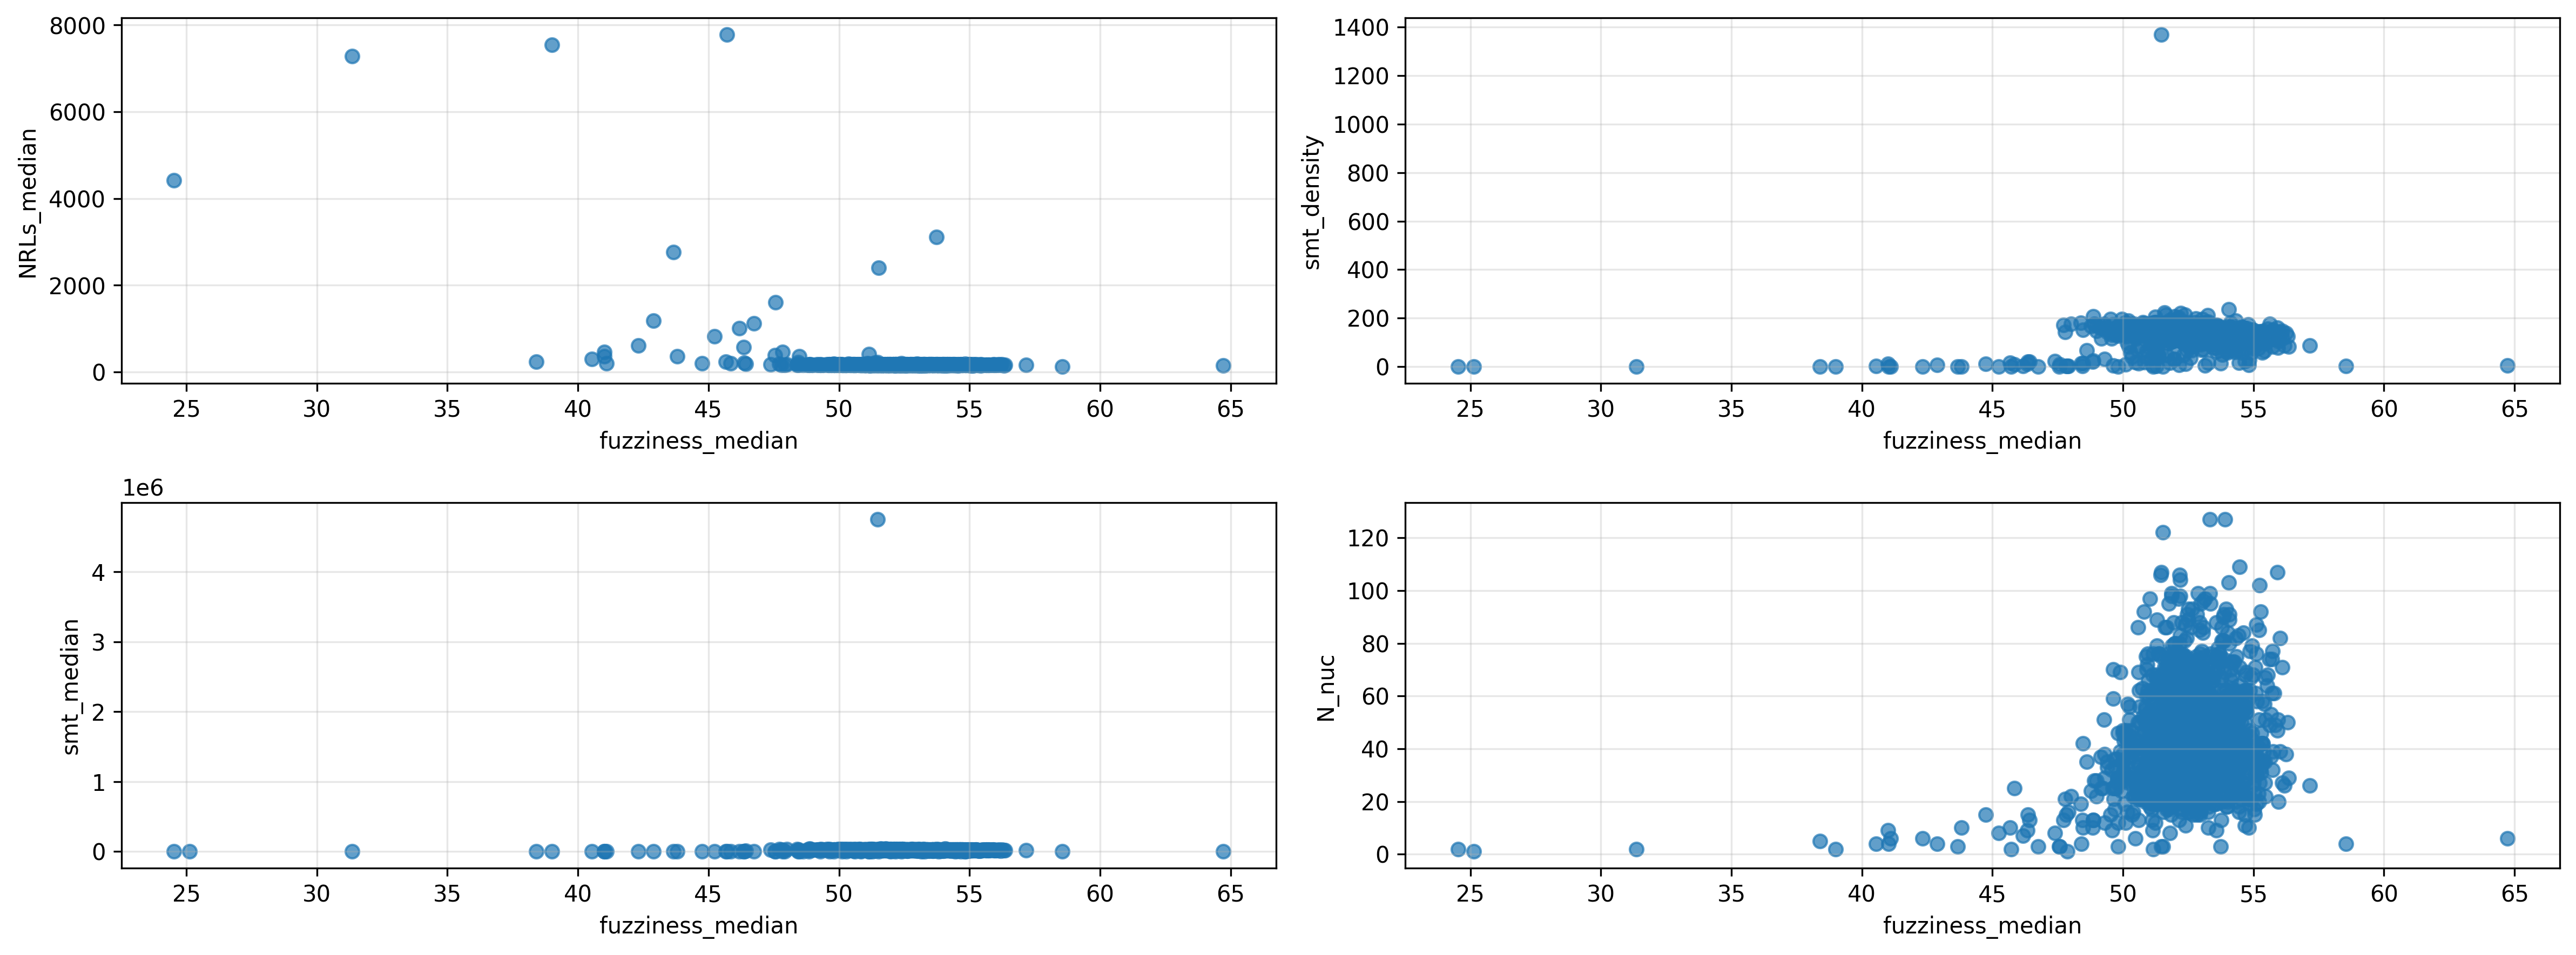

In [11]:
fig, ((ax1, ax2), (ax3, ax4)) = plt.subplots(figsize=(16,6), ncols=2, nrows=2, dpi=300)

NRLs_median      = df_CARs["NRLs_median"].to_numpy()
fuzziness_median = df_CARs["fuzziness_median"].to_numpy()
smt_density      = df_CARs["smt_density"].to_numpy()
smt_median       = df_CARs["smt_median"].to_numpy()
N_nuc            = df_CARs["N_nuc"].to_numpy()

ax1.scatter(fuzziness_median, NRLs_median, alpha=0.70)
ax1.set_xlabel("fuzziness_median")
ax1.set_ylabel("NRLs_median")
ax1.grid(True, which="both", alpha=0.30)

ax2.scatter(fuzziness_median, smt_density, alpha=0.70)
ax2.set_xlabel("fuzziness_median")
ax2.set_ylabel("smt_density")
ax2.grid(True, which="both", alpha=0.30)

ax3.scatter(fuzziness_median, smt_median, alpha=0.70)
ax3.set_xlabel("fuzziness_median")
ax3.set_ylabel("smt_median")
ax3.grid(True, which="both", alpha=0.30)

ax4.scatter(fuzziness_median, N_nuc, alpha=0.70)
ax4.set_xlabel("fuzziness_median")
ax4.set_ylabel("N_nuc")
ax4.grid(True, which="both", alpha=0.30)

plt.tight_layout()
plt.show()

# .